# **Semi-Guided Practice**

## Objectives

* This is an exercise for the sake of getting reps in whilst still trying to digest the on coming course material

* Using AI to create practice scenarios, with the aim of whittling out the guidance as I progress

* Based on the Iris dataset, handed out in virtual class for practice

* Output
This notebook will contain the EDA process, produce the visualisations and further statistical tests.




---

# Change working directory

* We are assuming you will store the notebooks in a subfolder, therefore when running the notebook in the editor, you will need to change the working directory

We need to change the working directory from its current folder to its parent folder
* We access the current directory with os.getcwd()

In [2]:
import os
current_dir = os.getcwd()
current_dir

'c:\\Users\\NateM\\Desktop\\CI_DA\\Practice_Projects\\pracIris\\jupyter_notebooks'

We want to make the parent of the current directory the new current directory
* os.path.dirname() gets the parent directory
* os.chir() defines the new current directory

In [3]:
os.chdir(os.path.dirname(current_dir))
print("You set a new current directory")

You set a new current directory


Confirm the new current directory

In [4]:
current_dir = os.getcwd()
current_dir

'c:\\Users\\NateM\\Desktop\\CI_DA\\Practice_Projects\\pracIris'

# Import block


In [5]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns 
import sklearn as sk

# Section 1 - Load the cleaned data

In [6]:
# Open the csv as a pandas dataframe

df_clean = pd.read_csv("Dataset/Cleaned/IrisCleaned.csv")

df_clean.head(10)


,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species,SepalArea,PetalArea
0,1,5.1,3.5,1.4,0.2,Iris-setosa,17.85,0.28
1,2,4.9,3.0,1.4,0.2,Iris-setosa,14.70,0.28
2,3,4.7,3.2,1.3,0.2,Iris-setosa,15.04,0.26
3,4,4.6,3.1,1.5,0.2,Iris-setosa,14.26,0.30
4,5,5.0,3.6,1.4,0.2,Iris-setosa,18.00,0.28
5,6,5.4,3.9,1.7,0.4,Iris-setosa,21.06,0.68
6,7,4.6,3.4,1.4,0.3,Iris-setosa,15.64,0.42
7,8,5.0,3.4,1.5,0.2,Iris-setosa,17.00,0.30
8,9,4.4,2.9,1.4,0.2,Iris-setosa,12.76,0.28
9,10,4.9,3.1,1.5,0.1,Iris-setosa,15.19,0.15


---

# Section 2 - EDA

We already know our distrubution across the Iris species is even, meaning each one is fairly represented.

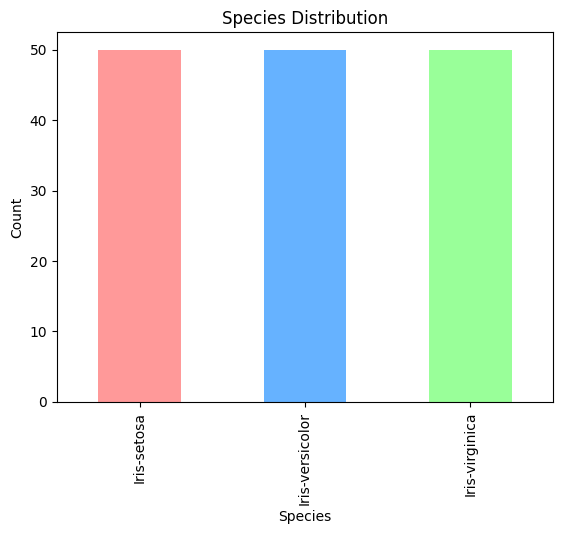

In [8]:
ax = df_clean["Species"].value_counts().plot(
    kind="bar",
    title="Species Distribution",
    xlabel="Species",
    ylabel="Count",
    color=["#FF9999", "#66B2FF", "#99FF99"]
)
plt.show()

Now let's inspect the plants measurements.

               count      mean       std  min  25%   50%  75%  max
PetalLengthCm  150.0  3.758667  1.764420  1.0  1.6  4.35  5.1  6.9
PetalWidthCm   150.0  1.198667  0.763161  0.1  0.3  1.30  1.8  2.5
SepalLengthCm  150.0  5.843333  0.828066  4.3  5.1  5.80  6.4  7.9
SepalWidthCm   150.0  3.054000  0.433594  2.0  2.8  3.00  3.3  4.4


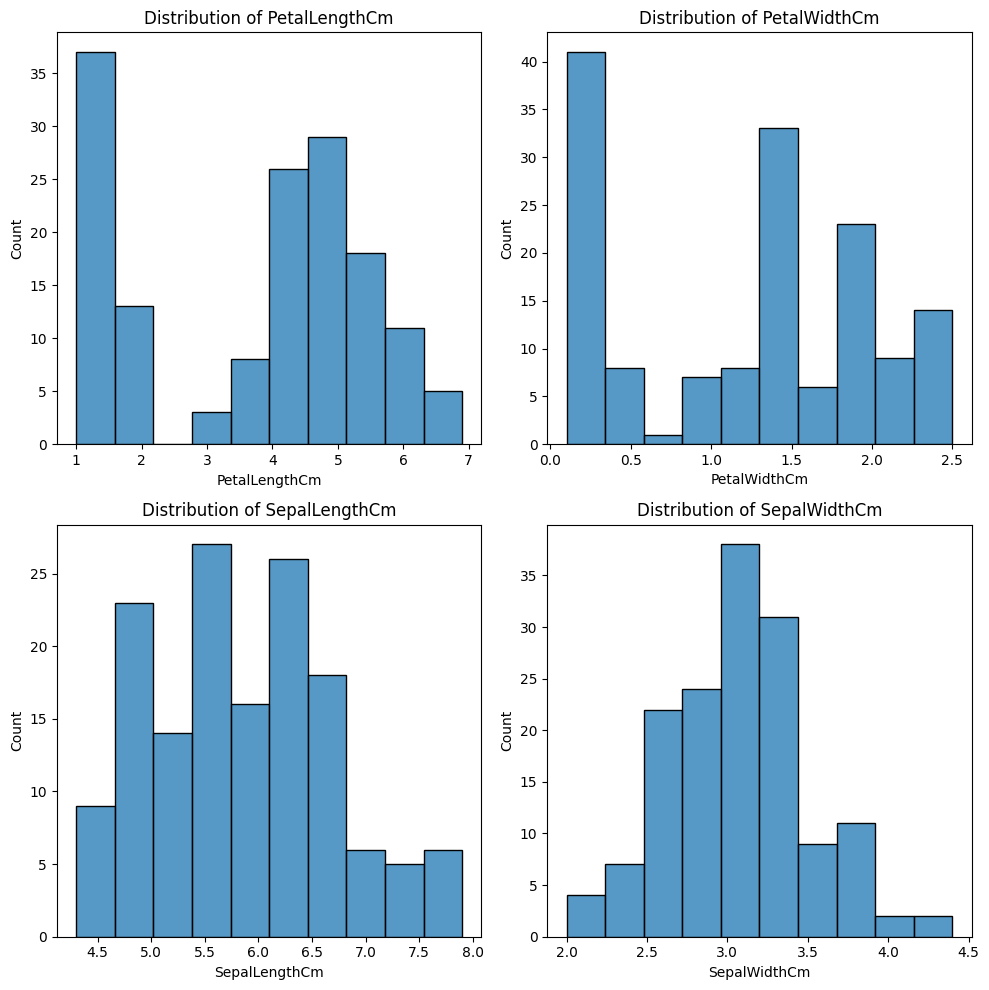

In [ ]:
# Condensing the columns to a list to work with

numeric_columns = [
    "PetalLengthCm",
    "PetalWidthCm",
    "SepalLengthCm",
    "SepalWidthCm",
]

# Raw numerical stat summary
print(df_clean[numeric_columns].describe().T)

# Visualise the distributions 
fig, axes = plt.subplots(2,2, figsize=(10,10))

for ax, column in zip(axes.flat, numeric_columns):
    sns.histplot(
        data=df_clean,
        x=column,
        bins=10,
        ax=ax
    )
    ax.set_title(
        f"Distribution of {column}"
    )
plt.tight_layout()
plt.show()

We can see that the petal length distribution, as well petal width, doesn't have simple shape having two distinct peaks. As well as this, the petal length's standard deviation shows it has a lot more variance within itself. This is likely to be a clustering within the species itself, which we'll explore further. 

Meanwhile both our sepal measurements follow a more typical distribution, with length seemingly clustered.

Let's see now see how the individual species themselves distribute.

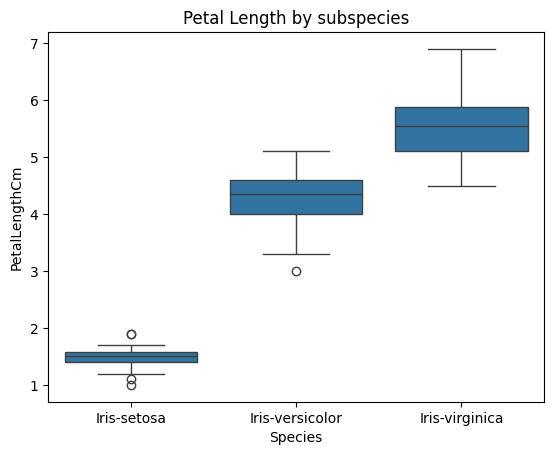

In [ ]:
# Plot the petal length via species

sns.boxplot(
    data=df_clean,
    x="Species",
    y="PetalLengthCm"
)
plt.title("Petal Length by subspecies")
plt.show()

We can see that Setosa petals are significantly shorter than Versicolor and Viriginica, with Viriginica having the largest. With no range overlap from Setosa to Versicolor and a small overlap between Versicolor and Virginica, that suggests petal length is a good feature to use for classifying the species. 

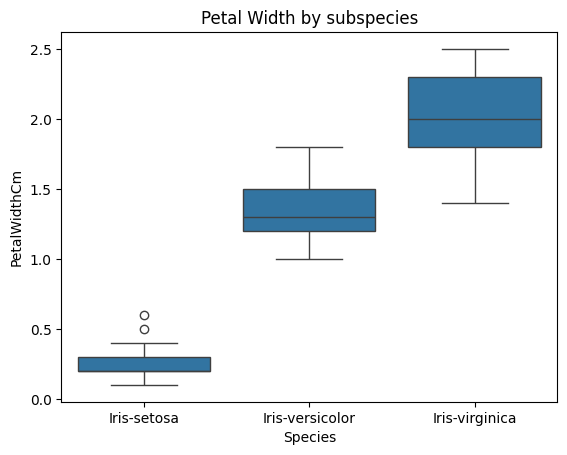

In [ ]:
# Plot the petal width via species

sns.boxplot(
    data=df_clean,
    x="Species",
    y="PetalWidthCm"
)
plt.title("Petal Width by subspecies")
plt.show()

We have a very similar outcome here with the petal width. Suggesting that the petal measurements are the ones to go by for classificiation. 

Let's compare against the sepal measurements to see if we have another anvenue for classification. 

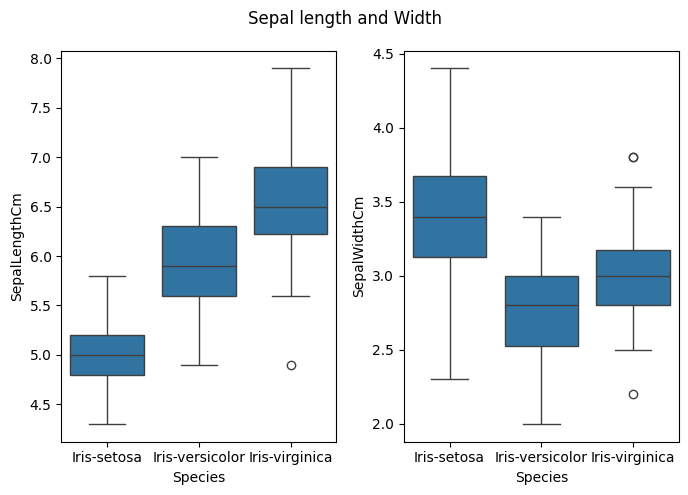

In [33]:
# Plot the sepal length via species

fig, axes = plt.subplots(1,2, figsize=(7,5))
fig.suptitle("Sepal length and Width")

sns.boxplot(
    data=df_clean,
    x="Species",
    y="SepalLengthCm",
    ax=axes[0]
    
)

sns.boxplot(
    data=df_clean,
    x="Species",
    y="SepalWidthCm",
    ax=axes[1]
)
plt.tight_layout()
plt.show()

---

# Section 2 - Transformation 

---